In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')
import numpy as np

import math
import cmath
np.set_printoptions(precision = 5)

<Token var=<ContextVar name='format_options' default={'edgeitems': 3, 'threshold': 1000, 'floatmode': 'maxprec', 'precision': 8, 'suppress': False, 'linewidth': 75, 'nanstr': 'nan', 'infstr': 'inf', 'sign': '-', 'formatter': None, 'legacy': 9223372036854775807, 'override_repr': None} at 0x111431300> at 0x1201e3bc0>

In [2]:
import matplotlib
import dizx
from dizx import Edge
from dizx import clifford_simplifier as simp
Phase = dizx.CliffordPhase
d = 3
Z = dizx.VertexType.Z
X = dizx.VertexType.X

In [3]:
"""Modules with tools for representing qudit Clifford matrices as symplectic matrices.
We are ignoring phases everywhere, and so everything is 'up to Paulis'.
The symplectic matrices are constructed according to the order (x1,z1,x2,z2,...) and hence not in terms of Z and X blocks.
"""
import os.path
# from sympy import symbols
from sympy import symbols, groebner, Matrix, eye, Symbol, mod_inverse

Hmat = Matrix([[0,-1],[1,0]])
H2mat = Matrix([[-1,0],[0,-1]])
Hinvmat = Matrix([[0,1],[-1,0]])
idmat = Matrix([[1,0],[0,1]])
SWAPmat = Matrix([
                [0,0,1,0],
                [0,0,0,1],
                [1,0,0,0],
                [0,1,0,0]])

def Smat(rep):
    """Create a matrix representing `rep` repetitions of the S gate."""
    return Matrix([[1  ,0],
                   [rep,1]])

def MULmat(mul, dim):
    return Matrix([[mul,0],
                   [0,mod_inverse(mul,dim)]])

def CXmat(rep):
    return Matrix([
                [1  ,0,0,0],
                [0  ,1,0,-rep],
                [rep,0,1,0],
                [0  ,0,0,1]])

def CZmat(rep):
    return Matrix([
                [1  ,0,0  ,0],
                [0  ,1,rep,0],
                [0  ,0,1  ,0],
                [rep,0,0  ,1]])

def embed_block(block, n, mapping):
    """
    Embed a 2k x 2k symplectic 'block' into a 2n x 2n matrix.
    
    Parameters
    ----------
    block   : sympy.Matrix (2k x 2k)
              Symplectic block defined on local qudits [0..k-1],
              ordered [x0, z0, x1, z1, ...].
    n       : int
              Total number of qudits in the global system.
    mapping : list[int]
              Mapping of local qudits to global qudits.
              E.g. [2,4] means local 0 → global 2, local 1 → global 4.
    """
    k = len(mapping)
    assert block.shape == (2*k, 2*k)

    M = eye(2*n)

    # Local-to-global index map
    idx = []
    for q in mapping:
        idx.extend([2*q, 2*q+1])  # (x_q, z_q) in global basis order

    # Place the block into M
    for r in range(2*k):
        for c in range(2*k):
            M[idx[r], idx[c]] = block[r, c]

    return M

def ID(num_qudits):
    return eye(2*num_qudits)

def H(target, num_qudits, reps=1):
    if reps % 4 == 1: mat = Hmat
    elif reps % 4 == 2: mat = H2mat
    elif reps % 4 == 3: mat = Hinvmat
    else: mat = idmat
    return embed_block(mat, num_qudits, [target])

def MUL(target, num_qudits, mul, dim):
    mat = MULmat(mul, dim)
    return embed_block(mat, num_qudits, [target])

def S(target, num_qudits, reps=1):
    mat = Smat(reps)
    return embed_block(mat, num_qudits, [target])


def CX(control, target, num_qudits, reps=1):
    mat = CXmat(reps)
    return embed_block(mat, num_qudits, [control,target])

def CZ(control, target, num_qudits, reps=1):
    mat = CZmat(reps)
    return embed_block(mat, num_qudits, [control,target])

def SWAP(control, target, num_qudits):
    return embed_block(SWAPmat, num_qudits, [control,target])

def modulo_matrix(M, p):
    reduced_entries = []
    for i in range(M.rows):
        row = M.row(i)
        newrow = []
        for entry in row:
            entry = entry % p 
            newrow.append(entry)
        reduced_entries.append(newrow)
    # Test
    # print(p)
    return Matrix(reduced_entries)

def reduce_matrix(M, params: list[tuple[Symbol,Symbol]]):
    """Given a matrix containing parameters, reduces it by applying simple identities.
    params should be a list of tuples (param, invparam) where we interpret invparam = param^{-1}"""
    
    flattened = [a for (a,ainv) in params] + [ainv for (a,ainv) in params]
    G = groebner([a*ainv - 1 for (a,ainv) in params], *flattened)

    reduced_entries = []
    for i in range(M.rows):
        row = M.row(i)
        newrow = []
        for entry in row:
            entry = G.reduce(entry)[1]  
            newrow.append(entry)
        reduced_entries.append(newrow)
    return Matrix(reduced_entries)

def compare_matrices(m1: Matrix, m2: Matrix, modulus: int = 0):
    if modulus != 0:
        m1 = modulo_matrix(m1,modulus)
        m2 = modulo_matrix(m2,modulus)
    return m1 == m2

def compare_matrices2(m1: Matrix, m2: Matrix, modulus: int = 0):
    if modulus != 0:
        a = symbols("a")
        ainv = symbols("ainv")
        b = symbols("b")
        binv = symbols("binv")
        m1_reduce = dizx.symplectic.reduce_matrix(m1,[(a,ainv),(b,binv)])
        m2_reduce = dizx.symplectic.reduce_matrix(m1,[(a,ainv),(b,binv)])
        m1_reduce = modulo_matrix(m1_reduce,modulus)
        m2_reduce = modulo_matrix(m2_reduce,modulus)
    return m1_reduce == m2_reduce

In [4]:
S = dizx.gates.S(0)
H = dizx.gates.HAD(0)

# Verify the symplectic version of single-qupit relations in Figure 1

In what follows, We use AB to denote two gates A and B composed in diagrammatic order.

- $C_2$: $H^4 \;\underset{}{\widehat{=}}\; I$.
- $C_3$: $S^p \;\underset{}{\widehat{=}}\; I$.
- $C_4$: $SHSHSH \;\underset{}{\widehat{=}}\; I$.
- $C_5$: $H^2SH^2S^{p-1} \;\underset{}{\widehat{=}}\; I$.

p= 23


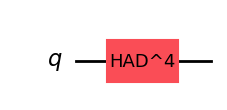

Matrix([[1, 0], [0, 1]])


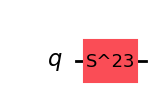

Matrix([[1, 0], [23, 1]])


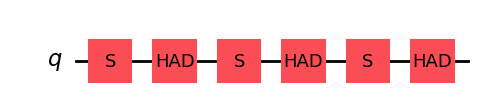

Matrix([[1, 0], [0, 1]])


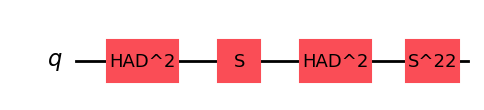

Matrix([[1, 0], [23, 1]])
OPENQASM 2.0;
include "qelib1.inc";
quditdim 23
qreg q[1];
h^4 q[0];



In [5]:
# from sympy import symbols
primes = [3, 5, 7, 11, 13, 19, 23]
for p in primes:
    C2lhs = dizx.Circuit(qudit_amount=1, dim=p)
    C2rhs = dizx.Circuit(qudit_amount=1, dim=p)
    C2lhs += H ** 4
    if dizx.symplectic.compare_matrices(C2lhs.to_symplectic_matrix(), C2rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Test C2 fails")

    C3lhs = dizx.Circuit(qudit_amount=1, dim=p)
    C3rhs = dizx.Circuit(qudit_amount=1, dim=p)
    C3lhs += S ** p
    if dizx.symplectic.compare_matrices(C3lhs.to_symplectic_matrix(), C3rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Test C3 fails")

    C4lhs = dizx.Circuit(qudit_amount=1, dim=p)
    C4rhs = dizx.Circuit(qudit_amount=1, dim=p)
    C4lhs += S + H + S + H + S + H
    if dizx.symplectic.compare_matrices(C4lhs.to_symplectic_matrix(), C4rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Test C4 fails")

    C5lhs = dizx.Circuit(qudit_amount=1, dim=p)
    C5rhs = dizx.Circuit(qudit_amount=1, dim=p)
    C5lhs += H ** 2 + S + H ** 2 + S ** (p-1)
    if dizx.symplectic.compare_matrices(C5lhs.to_symplectic_matrix(), C5rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Test C5 fails")

# Output the symplectic matrices
print("p=", p)
display(C2lhs.draw())
print(C2lhs.to_symplectic_matrix())
display(C3lhs.draw())
print(C3lhs.to_symplectic_matrix())
display(C4lhs.draw()) 
print(C4lhs.to_symplectic_matrix())   
display(C5lhs.draw()) 
print(C5lhs.to_symplectic_matrix())
print(C2lhs.to_qasm())


# Output the qasm file
save_to_path = '/Users/sarahli/Desktop/PhD-Projects/2025/QupitClifford-Verification/circuits'
name_of_file = 'C2-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fC2:
    fC2.write(C2lhs.to_qasm())

name_of_file = 'C3-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fC3:
    fC3.write(C3lhs.to_qasm())

name_of_file = 'C4-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fC4:
    fC4.write(C4lhs.to_qasm())

name_of_file = 'C5-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fC5:
    fC5.write(C5lhs.to_qasm())

# Verify the action of A boxes on the Pauli generators
- $A_{0b}$, $b \in \mathbb{Z}_p^*$
- $A_{ab}$, $a \in \mathbb{Z}_p^*$, $b \in \mathbb{Z}_p$

In [ ]:
# from sympy import symbols, Symbol

# def symbolic_inverse(x):
#     """
#     Given an expression like c*x where x is a Symbol and c is numeric/symbolic:
#         x      -> xinv
#        -x      -> -1 * xinv
#         3*x    -> 3**(-1) * xinv
#        -5*x    -> (-5)**(-1) * xinv
#     Returns a purely symbolic inverse expression.
#     """
#     # If x is just a bare symbol
#     if isinstance(x, Symbol):
#         return symbols(f"{x.name}inv")

#     # Try to decompose x = coeff * base
#     coeff, base = x.as_coeff_Mul()

#     if isinstance(base, Symbol):
#         inv_symbol = symbols(f"{base.name}inv")
#         inv_coeff = coeff**-1
#         return inv_coeff * inv_symbol

#     raise ValueError(f"Cannot compute symbolic inverse of expression: {x}")


In [ ]:
# b, c = symbols("b c")

# symbolic_inverse(b)
# # binv

# symbolic_inverse(3*b)
# # 3**(-1) * binv

# symbolic_inverse(-b)
# # (-1)**(-1) * binv  → simplifies to -1*binv

# symbolic_inverse(b - c)
# # (b - c)**(-1)

# symbolic_inverse(2*b + 3*c)
# # (2*b + 3*c)**(-1)


ValueError: Cannot compute symbolic inverse of expression: b - c

In [ ]:
# from sympy import symbols, Symbol, Add, Mul

# def symbolic_inverse(x):
#     """
#     Compute a symbolic multiplicative inverse of x.

#     Cases:
#         x is a Symbol:
#             x      -> xinv

#         x is coeff * Symbol:
#             3*x    -> 3**(-1) * xinv
#             -5*x   -> (-5)**(-1) * xinv

#         x is a linear combination like b - c or 2*b + 3*c:
#             b - c  -> (b - c)**(-1)

#         Otherwise:
#             fall back to x**(-1)
#     """

#     # Case 1: bare symbol → symbolic inverse symbol
#     if isinstance(x, Symbol):
#         return symbols(f"{x.name}inv")

#     # Decompose multiplicative factors
#     coeff, base = x.as_coeff_Mul()

#     # Case 2: x = coeff * Symbol
#     if isinstance(base, Symbol):
#         inv_symbol = symbols(f"{base.name}inv")
#         inv_coeff = coeff**-1
#         return inv_coeff * inv_symbol

#     # Case 3: additive expression (e.g., b - c)
#     if isinstance(x, Add):
#         # The whole expression behaves as a single multiplicative unit
#         return x**(-1)

#     # Default fallback: multiplicative inverse of the entire expression
#     return x**(-1)


In [79]:
from sympy import symbols, Symbol, Add, sympify

def symbolic_inverse(x):
    """
    Compute a symbolic multiplicative inverse of x.
    """
    # Convert Python ints/floats/etc. to SymPy objects
    x = sympify(x)

    # Case 1: bare symbol → symbolic inverse symbol
    if isinstance(x, Symbol):
        return symbols(f"{x.name}inv")

    # Decompose multiplicative factors
    coeff, base = x.as_coeff_Mul()

    # Case 2: x = coeff * Symbol
    if isinstance(base, Symbol):
        inv_symbol = symbols(f"{base.name}inv")
        inv_coeff = coeff**-1
        return inv_coeff * inv_symbol

    # Case 3: additive expression (e.g., b - c)
    if isinstance(x, Add):
        return x**(-1)

    # Default fallback
    return x**(-1)


In [80]:
b, c = symbols("b c")

symbolic_inverse(b)
# binv

symbolic_inverse(3*b)
# 3**(-1) * binv

symbolic_inverse(-1)

symbolic_inverse(-b)
# (-1)**(-1) * binv  → simplifies to -1*binv

symbolic_inverse(b - c)
# (b - c)**(-1)

symbolic_inverse(2*b + 3*c)
# (2*b + 3*c)**(-1)

1/(2*b + 3*c)

In [81]:
from dizx.circuit.gates import SWAP, CZ, CX, HAD, S

def instantiate_A_box(a, b, j, n, p):
    """
    Returns the A(a,b) box acting on qudit j inside an n-qudit circuit. Indexing starts from 0.
    """

    # ---- Index validation ----
    if not isinstance(j, int):
        raise TypeError(f"Target index j must be an integer, not {type(j)}.")

    if j < 0 or j >= n:
        raise ValueError(
            f"Target qudit index j={j} is out of range for n={n}. "
            f"Valid indices are 0 to {n-1}."
        )

    # ---- Create full circuit ----
    circ = dizx.Circuit(qudit_amount=n, dim=p)

    # ---- Case A(0,b) ----
    if a == 0:
        circ += (
            HAD(j)**-1 +
            S(j)**symbolic_inverse(b) +
            HAD(j)**-1 +
            S(j)**b +
            HAD(j)
        )
        return circ

    # ---- Case A(a,b), a != 0 ----
    circ += (
        HAD(j)**-1 +
        S(j)**(-a) +
        HAD(j)**-1 +
        S(j)**(-symbolic_inverse(a)) +
        HAD(j)**-1 +
        S(j)**(-a * (b + 1)) +
        HAD(j)
    )
    return circ


In [29]:
a = symbols("a")
b = symbols("b")
A0b_0 = instantiate_A_box(0, b, 0, 3, 23)
A0b_0_reduce = dizx.symplectic.reduce_matrix(A0b_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
A0b_0_reduce

# for i in range(10):
#     A0b_1 = instantiate_A_box(0, b, i, 10, 23)
#     A0b_1_reduce = dizx.symplectic.reduce_matrix(A0b_1.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     A0b_1_reduce
#     display(A0b_1.draw())


Matrix([
[ b,    0, 0, 0, 0, 0],
[-1, binv, 0, 0, 0, 0],
[ 0,    0, 1, 0, 0, 0],
[ 0,    0, 0, 1, 0, 0],
[ 0,    0, 0, 0, 1, 0],
[ 0,    0, 0, 0, 0, 1]])

In [30]:
a = symbols("a")
b = symbols("b")
c = symbols("c")
d = symbols("d")
A0d_0 = instantiate_A_box(0, d, 0, 3, 23)
A0d_0_reduce = dizx.symplectic.reduce_matrix(A0d_0.to_symplectic_matrix(),[(d,symbolic_inverse(d))])
A0d_0_reduce

# for i in range(10):
#     A0d_i = instantiate_A_box(0, d, i, 10, 23)
#     A0d_i_reduce = dizx.symplectic.reduce_matrix(A0d_i.to_symplectic_matrix(),[(d,symbolic_inverse(d))])
#     A0d_i_reduce
#     display(A0d_i.draw())
# A0d_i_reduce

Matrix([
[ d,    0, 0, 0, 0, 0],
[-1, dinv, 0, 0, 0, 0],
[ 0,    0, 1, 0, 0, 0],
[ 0,    0, 0, 1, 0, 0],
[ 0,    0, 0, 0, 1, 0],
[ 0,    0, 0, 0, 0, 1]])

In [31]:
a = symbols("a")
b = symbols("b")
Ab0_0 = instantiate_A_box(b, 0, 0, 3, 23)
Ab0_0_reduce = dizx.symplectic.reduce_matrix(Ab0_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Ab0_0_reduce

# for i in range(10):
#     Ab0_0 = instantiate_A_box(b, 0, i, 10, 23)
#     Ab0_0_reduce = dizx.symplectic.reduce_matrix(Ab0_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     Ab0_0_reduce
#     display(Ab0_0.draw())
# Ab0_0_reduce

Matrix([
[   0, -b, 0, 0, 0, 0],
[binv,  0, 0, 0, 0, 0],
[   0,  0, 1, 0, 0, 0],
[   0,  0, 0, 1, 0, 0],
[   0,  0, 0, 0, 1, 0],
[   0,  0, 0, 0, 0, 1]])

In [33]:
a = symbols("a")
b = symbols("b")
Aa0_0 = instantiate_A_box(a, 0, 0, 1, 23)
Aa0_0_reduce = dizx.symplectic.reduce_matrix(Aa0_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Aa0_0_reduce

# for i in range(10):
#     Aa0_0 = instantiate_A_box(a, 0, i, 10, 23)
#     Aa0_0_reduce = dizx.symplectic.reduce_matrix(Aa0_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     Aa0_0_reduce
#     display(Aa0_0.draw())

# Aa0_0_reduce

Matrix([
[   0, -a],
[ainv,  0]])

In [34]:
a = symbols("a")
b = symbols("b")
A0_neg_a = instantiate_A_box(0, -a, 0, 1, 23)
A0_neg_a_reduce = dizx.symplectic.reduce_matrix(A0_neg_a.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
A0_neg_a_reduce

# for i in range(10):
#     A0_neg_a = instantiate_A_box(0, -a, i, 10, 23)
#     A0_neg_a_reduce = dizx.symplectic.reduce_matrix(A0_neg_a.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     display(A0_neg_a.draw())

# A0_neg_a_reduce

Matrix([
[-a,     0],
[-1, -ainv]])

In [35]:
a = symbols("a")
b = symbols("b")
Ab_neg_a = instantiate_A_box(b, -a, 0, 1, 23)
Ab_neg_a_reduce = dizx.symplectic.reduce_matrix(Ab_neg_a.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Ab_neg_a_reduce

# for i in range(10):
#     Ab_neg_a = instantiate_A_box(b, -a, i, 10, 23)
#     Ab_neg_a_reduce = dizx.symplectic.reduce_matrix(Ab_neg_a.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     display(Ab_neg_a.draw())

# Ab_neg_a_reduce

Matrix([
[  -a, -b],
[binv,  0]])

In [61]:
a = symbols("a")
b = symbols("b")
Aa_bminusa = instantiate_A_box(a, b-a, 0, 1, 23)
Aa_bminusa_reduce = dizx.symplectic.reduce_matrix(Aa_bminusa.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Aa_bminusa_reduce

# for i in range(10):
#     Aa_bminusa = instantiate_A_box(a, b-a, i, 10, 23)
#     Aa_bminusa_reduce = dizx.symplectic.reduce_matrix(Aa_bminusa.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     display(Aa_bminusa.draw())

# Aa_bminusa_reduce

Matrix([
[-a + b, -a],
[  ainv,  0]])

In [37]:
a = symbols("a")
b = symbols("b")
Aab = instantiate_A_box(a, b, 0, 1, 23)
Aab_reduce = dizx.symplectic.reduce_matrix(Aab.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Aab_reduce

# for i in range(10):
#     Aab = instantiate_A_box(a, b, i, 10, 23)
#     Aab_reduce = dizx.symplectic.reduce_matrix(Aab.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     display(Aab.draw())

# Aab_reduce

Matrix([
[   b, -a],
[ainv,  0]])

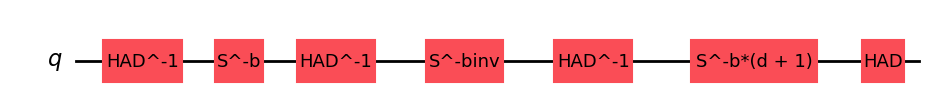

Matrix([
[   d, -b],
[binv,  0]])

In [38]:
b = symbols("b")
d = symbols("d")
Abd = instantiate_A_box(b, d, 0, 1, 23)
Abd_reduce = dizx.symplectic.reduce_matrix(Abd.to_symplectic_matrix(),[(b,symbolic_inverse(b)),(d,symbolic_inverse(d))])
display(Abd.draw())
Abd_reduce

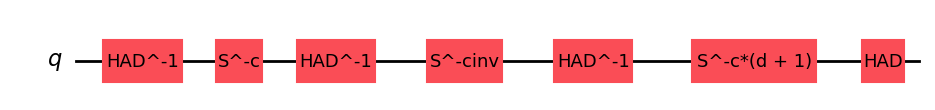

Matrix([
[   d, -c],
[cinv,  0]])

In [45]:
c = symbols("c")
d = symbols("d")
Acd = instantiate_A_box(c, d, 0, 1, 23)
Acd_reduce = dizx.symplectic.reduce_matrix(Acd.to_symplectic_matrix(),[(c,symbolic_inverse(c)),(d,symbolic_inverse(d))])
display(Acd.draw())
Acd_reduce

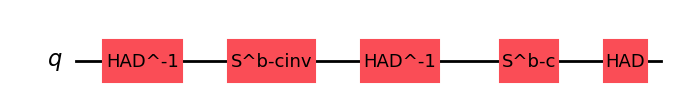

In [ ]:
a = symbols("a")
b = symbols("b")
c = symbols("c")
d = symbols("d")
bminusc = symbols("b-c")
A0_bminusc = instantiate_A_box(0, bminusc, 0, 1, 23)
A0_bminusc_reduce = dizx.symplectic.reduce_matrix(A0_bminusc.to_symplectic_matrix(),[(bminusc,symbolic_inverse(bminusc))])
A0_bminusc_reduce
display(A0_bminusc.draw())

In [59]:
b = symbols("b")
c = symbols("c")
bminusc = symbols("b-c")
m = dizx.Circuit(qudit_amount=1, dim=23)
m += HAD(0)**-1 + S(0)**(symbolic_inverse(bminusc)) + HAD(0)**-1 + S(0)**(bminusc) + HAD(0)
m.to_symplectic_matrix()
m_reduce = dizx.symplectic.reduce_matrix(m.to_symplectic_matrix(),[(bminusc,symbolic_inverse(bminusc))])
m_reduce
# m.to_symplectic_matrix()

Matrix([
[b-c,      0],
[ -1, b-cinv]])

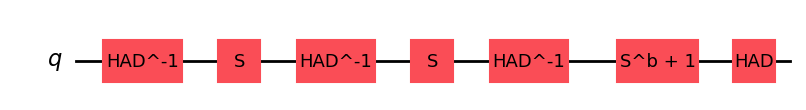

Matrix([
[ b, 1],
[-1, 0]])

In [78]:
a = symbols("a")
b = symbols("b")
c = symbols("c")
d = symbols("d")
t = symbols("t")
Aminus1_b = instantiate_A_box(-1, b, 0, 1, 23)
Aminus1_b_reduce = dizx.symplectic.reduce_matrix(Aminus1_b.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
display(Aminus1_b.draw())
Aminus1_b_reduce

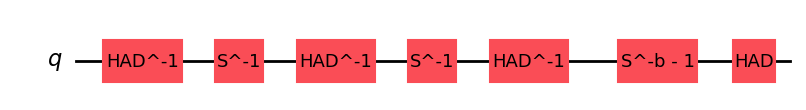

Matrix([
[b, -1],
[1,  0]])

In [82]:
a = symbols("a")
b = symbols("b")
c = symbols("c")
d = symbols("d")
t = symbols("t")
A1b = instantiate_A_box(1, b, 0, 1, 23)
A1b_reduce = dizx.symplectic.reduce_matrix(A1b.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
display(A1b.draw())
A1b_reduce

In [86]:
a = symbols("a")
b = symbols("b")
c = symbols("c")
d = symbols("d")
# bminusc = symbols("b-c")
A0_1minusa = instantiate_A_box(0, 1-a, 0, 1, 23)
A0_1minusa_reduce = dizx.symplectic.reduce_matrix(A0_1minusa.to_symplectic_matrix(),[(1-a,symbolic_inverse(1-a))])
display(A0_1minusa.draw())
A0_1minusa_reduce

CoercionFailed: expected an integer, got 1 - a

In [34]:
# Define A and E boxes that appear in the single-qupit box relations
a = symbols("a")
ainv = symbols("ainv")
b = symbols("b")
binv = symbols("binv")

A0b = dizx.Circuit(qudit_amount=1, dim=p)
A0b += H**-1 + S**binv + H**-1 + S**b + H

Aab = dizx.Circuit(qudit_amount=1, dim=p)
Aab += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b+1)) + H

Ab0 = dizx.Circuit(qudit_amount=1, dim=p)
Ab0 += H**-1 + S**-b + H**-1 + S**-binv + H**-1 + S**(-b) + H

Aa0 = dizx.Circuit(qudit_amount=1, dim=p)
Aa0 += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a) + H

A0_neg_a = dizx.Circuit(qudit_amount=1, dim=p)
A0_neg_a += H**-1 + S**-ainv + H**-1 + S**-a + H

Ab_neg_a = dizx.Circuit(qudit_amount=1, dim=p)
Ab_neg_a += H**-1 + S**-b + H**-1 + S**-binv + H**-1 + S**(-b*(-a+1)) + H

Aa_bminusa = dizx.Circuit(qudit_amount=1, dim=p)
Aa_bminusa += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b-a+1)) + H

Eb = dizx.Circuit(qudit_amount=1, dim=p)
Eb += S**(-b)

E_bminus1 = dizx.Circuit(qudit_amount=1, dim=p)
E_bminus1 += S**-(b-1)

In [36]:
A0b_m = A0b.to_symplectic_matrix()
A0b_m_reduce = dizx.symplectic.reduce_matrix(A0b_m,[(a,ainv),(b,binv)])
Aab_m = Aab.to_symplectic_matrix()
Aab_m_reduce = dizx.symplectic.reduce_matrix(Aab_m,[(a,ainv),(b,binv)])

print(A0b_m_reduce)
print(Aab_m_reduce)

name_of_file = 'A0b'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fA0b:
    fA0b.write(A0b.to_qasm())

name_of_file = 'Aab'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fAab:
    fAab.write(Aab.to_qasm())
# print(p)

Matrix([[b, 0], [-1, binv]])
Matrix([[b, -a], [ainv, 0]])


# Verify the action of E boxes on the Pauli generators
- $E_{b}$, $b \in \mathbb{Z}_p$

In [22]:
def instantiate_E_box(b, j, n, p):
    """
    Returns the E(b) box acting on qudit j inside an n-qudit circuit. Indexing starts from 0.
    """

    # ---- Index validation ----
    if not isinstance(j, int):
        raise TypeError(f"Target index j must be an integer, not {type(j)}.")

    if j < 0 or j >= n:
        raise ValueError(
            f"Target qudit index j={j} is out of range for n={n}. "
            f"Valid indices are 0 to {n-1}."
        )

    # ---- Create full circuit ----
    circ = dizx.Circuit(qudit_amount=n, dim=p)
    circ += S(j)**(-b)
    return circ


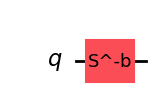

Matrix([
[ 1, 0],
[-b, 1]])

In [26]:
Eb = instantiate_E_box(b, 0, 1, 23)
Eb_reduce = dizx.symplectic.reduce_matrix(Eb.to_symplectic_matrix(),[(b,symbolic_inverse(b))])
display(Eb.draw())
Eb_reduce

# for i in range(10):
#     Eb = instantiate_E_box(b, i, 10, 23)
#     Eb_reduce = dizx.symplectic.reduce_matrix(Eb.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     display(Eb.draw())

# Eb_reduce

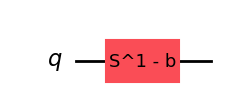

Matrix([
[    1, 0],
[1 - b, 1]])

In [29]:
E_bminus1 = instantiate_E_box(b-1, 0, 1, 23)
E_bminus1_reduce = dizx.symplectic.reduce_matrix(E_bminus1.to_symplectic_matrix(),[(b,symbolic_inverse(b))])
display(E_bminus1.draw())
E_bminus1_reduce

# for i in range(10):
#     E_bminus1 = instantiate_E_box(b-1, i, 10, 23)
#     E_bminus1_reduce = dizx.symplectic.reduce_matrix(E_bminus1.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
#     display(E_bminus1.draw())

# E_bminus1_reduce

# Verify the action of B boxes on the Pauli generators
- $B_{00}$,
- $B_{01}$,
- $B_{ab}$.

In [30]:
from dizx.circuit.gates import SWAP, CX, HAD, S
import dizx

def instantiate_B_box(a, b, j, k, n, p):
    """
    Instantiate a B(a,b) box acting on qudits j and k inside an n-qudit circuit.
    B-boxes act only on adjacent qudits, i.e., |j - k| = 1.
    """

    # ---- Index validation ----
    for idx, name in [(j, "j"), (k, "k")]:
        if not isinstance(idx, int):
            raise TypeError(f"Target index {name} must be an integer, not {type(idx)}.")

        if idx < 0 or idx >= n:
            raise ValueError(
                f"Target qudit index {name}={idx} is out of range for n={n}. "
                f"Valid indices are 0 to {n-1}."
            )

    # ---- Adjacency validation ----
    if abs(j - k) != 1:
        raise ValueError(
            f"B-box Bab can only act on adjacent qudits, but got j={j}, k={k}."
        )

    # ---- Create full circuit ----
    circ = dizx.Circuit(qudit_amount=n, dim=p)

    # ---- Case B00: just SWAP ----
    if a == 0 and b == 0:
        circ += SWAP(j, k)
        return circ

    # ---- Case B01: SWAP + CX(1,0) ----
    if a == 0 and b == 1:
        circ += SWAP(j, k)
        circ += CX(k, j)
        return circ

    # ---- General case Bab = Aab(j) + B01(j,k) ----

    # Instantiate Aab on qudit j
    Aab_j = instantiate_A_box(a, b, j, n, p)
    circ += Aab_j

    # Add B01(j,k)
    circ += SWAP(j, k)
    circ += CX(k, j)

    return circ


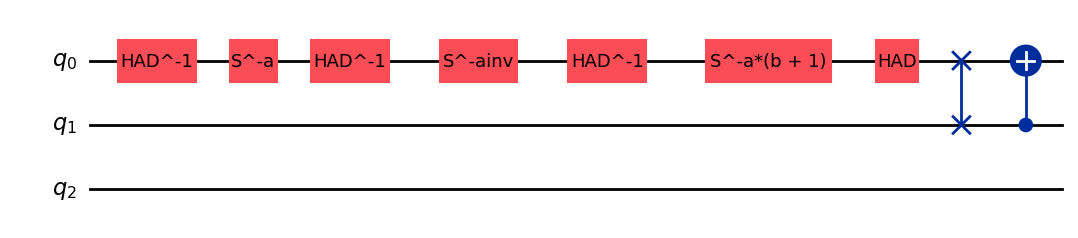

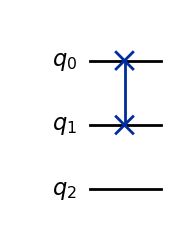

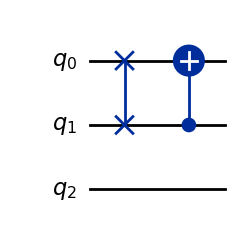

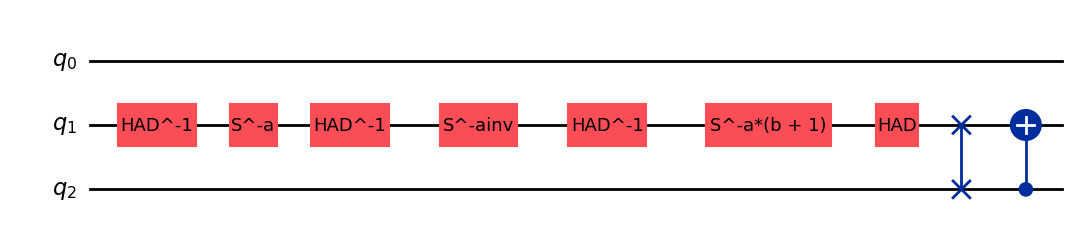

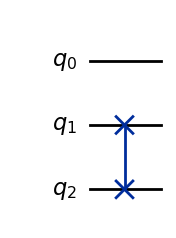

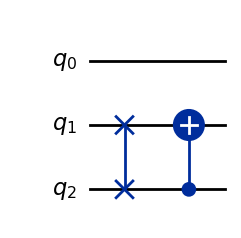

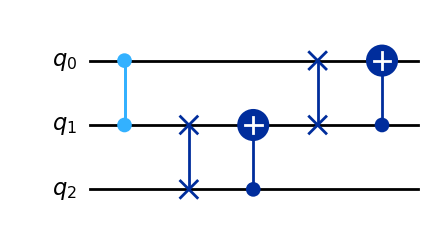

In [38]:
# Works (adjacent qudits)
Bab_01 = instantiate_B_box(a, b, j=0, k=1, n=3, p=23)
display(Bab_01.draw())

B00_01 = instantiate_B_box(0, 0, j=0, k=1, n=3, p=23)
display(B00_01.draw())

B01_01 = instantiate_B_box(0, 1, j=0, k=1, n=3, p=23)
display(B01_01.draw())

Bab_12 = instantiate_B_box(a, b, j=1, k=2, n=3, p=23)
display(Bab_12.draw())

B00_12 = instantiate_B_box(0, 0, j=1, k=2, n=3, p=23)
display(B00_12.draw())

B01_12 = instantiate_B_box(0, 1, j=1, k=2, n=3, p=23)
display(B01_12.draw())
# Error: not adjacent
# Bab = instantiate_B_box(a, b, j=1, k=4, n=7, p=23)
# ValueError: B-box Bab can only act on adjacent qudits

lhs = dizx.Circuit(qudit_amount=3, dim=3)
lhs += CZ(0,1) + B01_12 + B01_01
display(lhs.draw())


# Verify the action of D boxes on the Pauli generators
- $D_{00}$,
- $D_{01}$,
- $D_{ab}$.

In [45]:
from dizx.circuit.gates import SWAP, CZ, HAD, S
import dizx

def instantiate_D_box(a, b, j, k, n, p):
    """
    Instantiate a D(a,b) box acting on qudits j and k inside an n-qudit circuit.

    Updated specification:
        D00 = SWAP(j,k)
        D0b = SWAP(j,k) + CZ(j,k)**(-b)
        Dab = Aab(on qudit k) + D01(j,k), valid only for a != 0
    """

    # ---- Index validation ----
    for idx, name in [(j, "j"), (k, "k")]:
        if not isinstance(idx, int):
            raise TypeError(f"Target index {name} must be an integer, not {type(idx)}.")

        if idx < 0 or idx >= n:
            raise ValueError(
                f"Target qudit index {name}={idx} is out of range for n={n}. "
                f"Valid indices are 0 to {n-1}."
            )

    # ---- Create empty circuit ----
    circ = dizx.Circuit(qudit_amount=n, dim=p)

    # ----------------------------------------------------------------------
    # Case 1: D00 = SWAP
    # ----------------------------------------------------------------------
    if a == 0 and b == 0:
        circ += SWAP(j, k)
        return circ

    # ----------------------------------------------------------------------
    # Case 2: D0b = SWAP + CZ**(-b)  (for ANY b)
    # ----------------------------------------------------------------------
    if a == 0:
        circ += SWAP(j, k)
        circ += CZ(j, k)**(-b)
        return circ

    # ----------------------------------------------------------------------
    # Case 3: General Dab = Aab(on second qudit) + D01
    # Allowed *only when a != 0*
    # ----------------------------------------------------------------------

    # Instantiate Aab on the SECOND qudit k
    Aab_k = instantiate_A_box(a, b, k, n, p)
    circ += Aab_k

    # Add D01
    circ += SWAP(j, k)
    circ += CZ(j, k)**(-1)   # this is b = 1 in D01

    return circ


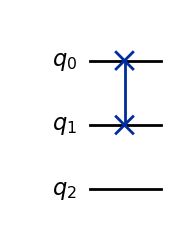

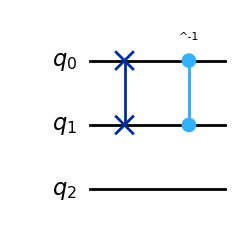

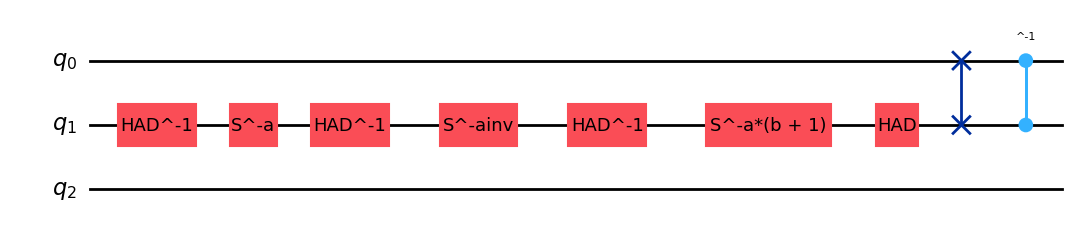

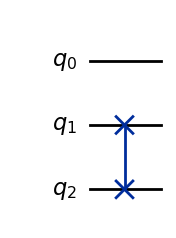

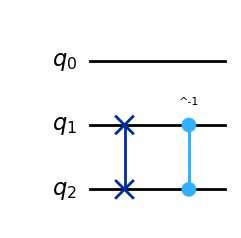

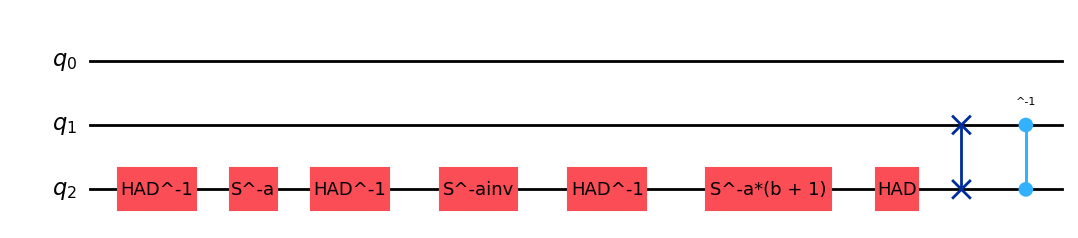

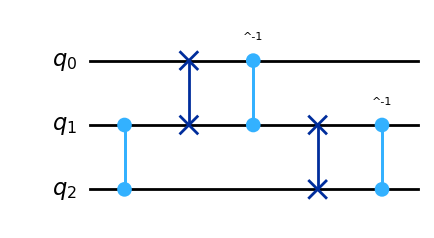

In [46]:
# D00 on (0,1)
D00_01 = instantiate_D_box(0, 0, j=0, k=1, n=3, p=23)
display(D00_01.draw())

# D01 on (0,1)
D01_01 = instantiate_D_box(0, 1, j=0, k=1, n=3, p=23)
display(D01_01.draw())

# Dab (general case) on (0,1)
Dab_01 = instantiate_D_box(a, b, j=0, k=1, n=3, p=23)
display(Dab_01.draw())

# D00 on (1,2)
D00_12 = instantiate_D_box(0, 0, j=1, k=2, n=3, p=23)
display(D00_12.draw())

# D01 on (1,2)
D01_12 = instantiate_D_box(0, 1, j=1, k=2, n=3, p=23)
display(D01_12.draw())

# Dab (general case) on (1,2)
Dab_12 = instantiate_D_box(a, b, j=1, k=2, n=3, p=23)
display(Dab_12.draw())




lhs = dizx.Circuit(qudit_amount=3, dim=3)
lhs += CZ(1,2) + D01_01 + D01_12
display(lhs.draw())

In [6]:
Eb_m = Eb.to_symplectic_matrix()
Eb_m_reduce = dizx.symplectic.reduce_matrix(Eb_m,[(b,binv)])

print(Eb_m_reduce)

name_of_file = 'Eb'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fEb:
    fEb.write(Eb.to_qasm())

NameError: name 'Eb' is not defined

# Single-qupit box relations

In [53]:
BR1lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR1rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR1lhs += H + A0b
BR1rhs += Ab0 + S**(-binv)

BR2lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR2rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR2lhs += H + Aa0
BR2rhs += A0_neg_a + S**(-ainv)

BR3lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR3rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR3lhs += H + Aab
BR3rhs += Ab_neg_a + S**(ainv * binv)

BR4lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR4rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR4lhs += S + A0b
BR4rhs += A0b + (S**binv)**binv

BR5lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR5rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR5lhs += S + Aab
BR5rhs += Aa_bminusa

BR6lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR6rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR6lhs += S + Eb
BR6rhs += E_bminus1

# Put all circuits into lists in order ---
lhs_list = [BR1lhs, BR2lhs, BR3lhs, BR4lhs, BR5lhs, BR6lhs]
rhs_list = [BR1rhs, BR2rhs, BR3rhs, BR4rhs, BR5rhs, BR6rhs]

# Give each pair a readable name (same order!)
relation_names = ["BR1", "BR2", "BR3", "BR4", "BR5", "BR6"]

## Verify the symplectic soundness of six single-qupit box relations
Also print LHS and RHS to qsam files

In [54]:
import os
primes = [3, 5, 7, 11, 13, 19, 23]

for p in primes:
    # Loop through all relations
    for name, lhs, rhs in zip(relation_names, lhs_list, rhs_list):
        # Compute symplectic matrices
        lhs_mat = lhs.to_symplectic_matrix()
        rhs_mat = rhs.to_symplectic_matrix()

        # Compare using your function
        ok = dizx.symplectic.compare_matrices2(lhs_mat, rhs_mat, modulus=p)

        if not ok:
            print(f"{name} fails.")

            # --- 3. Save LHS and RHS QASM files ---
            lhs_filename = os.path.join(save_to_path, f"{name}-lhs.qasm")
            rhs_filename = os.path.join(save_to_path, f"{name}-rhs.qasm")

            with open(lhs_filename, "w+") as f:
                f.write(lhs.to_qasm())

            with open(rhs_filename, "w+") as f:
                f.write(rhs.to_qasm())

## Print all single-qupit box relations as circuits

BR1-LHS:


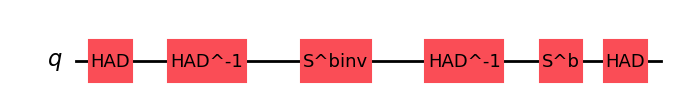

BR1-RHS:


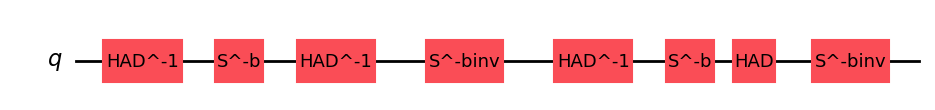

BR2-LHS:


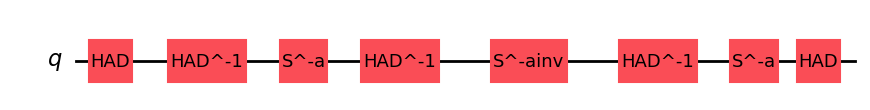

BR2-RHS:


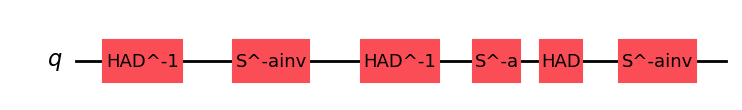

BR3-LHS:


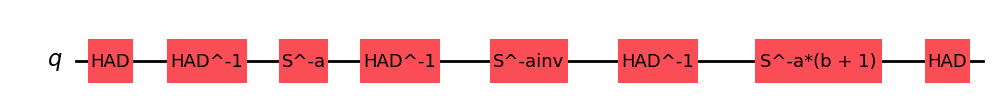

BR3-RHS:


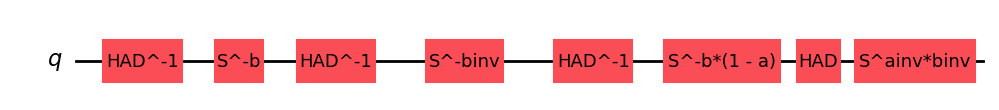

BR4-LHS:


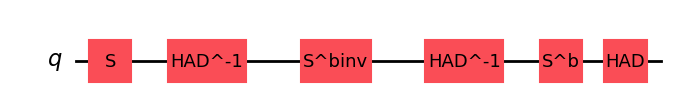

BR4-RHS:


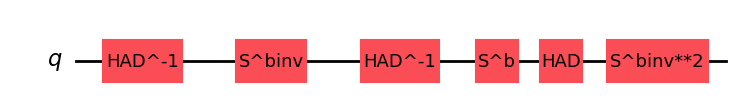

BR5-LHS:


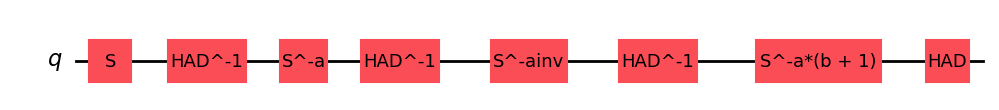

BR5-RHS:


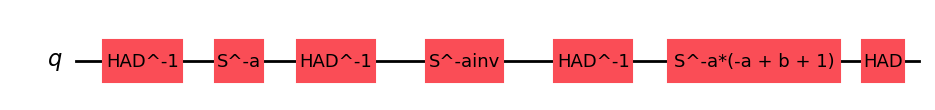

BR6-LHS:


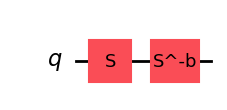

BR6-RHS:


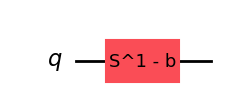

In [55]:
from IPython.display import display

# Loop and display drawings
for name, lhs, rhs in zip(relation_names, lhs_list, rhs_list):
    print(f"{name}-LHS:")
    display(lhs.draw())

    print(f"{name}-RHS:")
    display(rhs.draw())

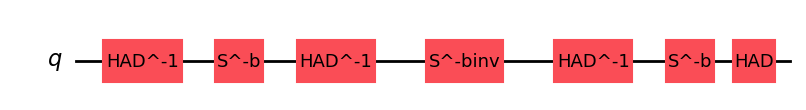

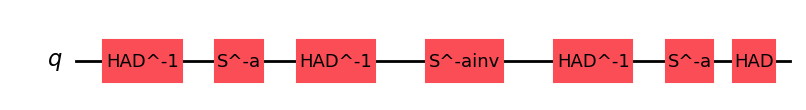

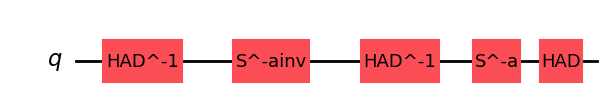

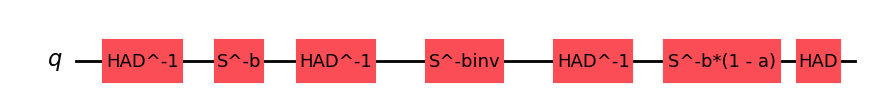

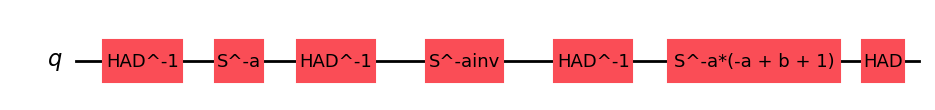

In [9]:
a = symbols("a")
b = symbols("b")
# ainv = symbols("ainv")

# binv = symbols("binv")

A0b_0 = instantiate_A_box(0, b, 0, 1, 23)
Aab_0 = instantiate_A_box(a, b, 0, 1, 23)
Ab0_0 = instantiate_A_box(b, 0, 0, 1, 23)
Aa0_0 = instantiate_A_box(a, 0, 0, 1, 23)
A0_neg_a = instantiate_A_box(0, -a, 0, 1, 23)
Ab_neg_a = instantiate_A_box(b, -a, 0, 1, 23)
Aa_bminusa = instantiate_A_box(a, b-a, 0, 1, 23)

A0b_0_reduce = dizx.symplectic.reduce_matrix(A0b_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
A0b_0_reduce
Aab_0_reduce = dizx.symplectic.reduce_matrix(Aab_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Aab_0_reduce
Ab0_0_reduce = dizx.symplectic.reduce_matrix(Ab0_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Ab0_0_reduce
display(Ab0_0.draw())
Aa0_0_reduce = dizx.symplectic.reduce_matrix(Aa0_0.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Aa0_0_reduce
display(Aa0_0.draw())
A0_neg_a_reduce = dizx.symplectic.reduce_matrix(A0_neg_a.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
A0_neg_a_reduce
display(A0_neg_a.draw())
Ab_neg_a_reduce = dizx.symplectic.reduce_matrix(Ab_neg_a.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Ab_neg_a_reduce
display(Ab_neg_a.draw())
Aa_bminusa_reduce = dizx.symplectic.reduce_matrix(Aa_bminusa.to_symplectic_matrix(),[(a,symbolic_inverse(a)),(b,symbolic_inverse(b))])
Aa_bminusa_reduce
display(Aa_bminusa.draw())
# Aab_m = Aab.to_symplectic_matrix()
# Aab_m_reduce = dizx.symplectic.reduce_matrix(Aab_m,[(a,ainv),(b,binv)])


In [ ]:
# Define A and E boxes that appear in the single-qupit box relations
a = symbols("a")
ainv = symbols("ainv")
b = symbols("b")
binv = symbols("binv")

A0b = dizx.Circuit(qudit_amount=1, dim=p)
A0b += H**-1 + S**binv + H**-1 + S**b + H

Aab = dizx.Circuit(qudit_amount=1, dim=p)
Aab += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b+1)) + H

Ab0 = dizx.Circuit(qudit_amount=1, dim=p)
Ab0 += H**-1 + S**-b + H**-1 + S**-binv + H**-1 + S**(-b) + H

Aa0 = dizx.Circuit(qudit_amount=1, dim=p)
Aa0 += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a) + H

A0_neg_a = dizx.Circuit(qudit_amount=1, dim=p)
A0_neg_a += H**-1 + S**-ainv + H**-1 + S**-a + H

Ab_neg_a = dizx.Circuit(qudit_amount=1, dim=p)
Ab_neg_a += H**-1 + S**-b + H**-1 + S**-binv + H**-1 + S**(-b*(-a+1)) + H

Aa_bminusa = dizx.Circuit(qudit_amount=1, dim=p)
Aa_bminusa += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b-a+1)) + H

Eb = dizx.Circuit(qudit_amount=1, dim=p)
Eb += S**(-b)

E_bminus1 = dizx.Circuit(qudit_amount=1, dim=p)
E_bminus1 += S**-(b-1)

# Verify the action of B boxes on the Pauli generators
- $B_{00}$, 
- $B_{01}$, 
- $B_{ab}$, $(a,b) \in \mathbb{Z}_p\times \mathbb{Z}_p\setminus\{(0,0),(0,1)\}$.

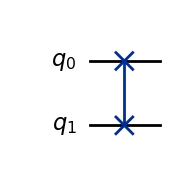

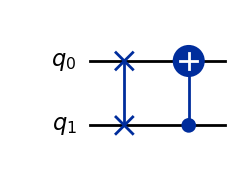

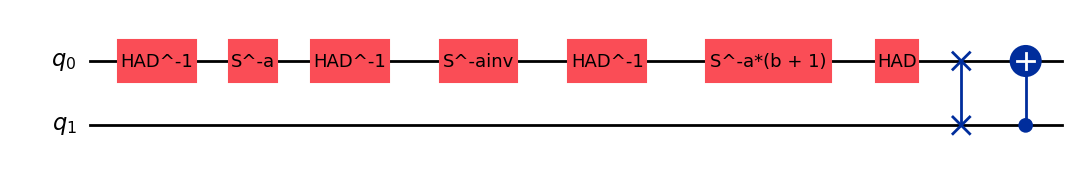

In [ ]:
from dizx.circuit.gates import SWAP, CZ, CX, HAD, S
def makeBbox(qudit_amount, dim, targets):
    
B00 = dizx.Circuit(qudit_amount=2, dim=23)
B00 += SWAP(0,1)
display(B00.draw())

B01 = dizx.Circuit(qudit_amount=2, dim=23)
B01 += SWAP(0,1)
B01 += CX(1,0)
display(B01.draw())

Bab = dizx.Circuit(qudit_amount=2, dim=23)
Bab += Aab + B01
display(Bab.draw())

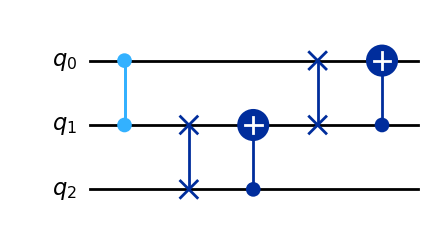

In [122]:
B01_12 = dizx.Circuit(qudit_amount=3, dim=3)
B01_12 += SWAP(1,2)
B01_12 += CX(2,1)

B01_01 = dizx.Circuit(qudit_amount=3, dim=3)
B01_01 += SWAP(0,1)
B01_01 += CX(1,0)

lhs = dizx.Circuit(qudit_amount=3, dim=3)
lhs += CZ(0,1) + B01_12 + B01_01
display(lhs.draw())

## Print the symplectic matrix of two-qupit gates and verify that their definition is consistent with the paper

In [80]:
SWAPmat
CXmat(1)
CX(1,0,2,p)
# modulo_matrix(CXmat(23), 23)
# SWAP(0,2,4)
# CX(0,2,4,1)
# CX(2,0,4,1)
CZ(0,1,3,23)
modulo_matrix(CZ(0,1,3,23), 23)
CZ(0,2,3,23)
modulo_matrix(CZ(0,2,3,23), 23)
CZ(1,0,3,23)
CZ(2,0,3,23)

Matrix([
[ 1, 0, 0, 0,  0, 0],
[ 0, 1, 0, 0, 23, 0],
[ 0, 0, 1, 0,  0, 0],
[ 0, 0, 0, 1,  0, 0],
[ 0, 0, 0, 0,  1, 0],
[23, 0, 0, 0,  0, 1]])

In [116]:
from dizx.circuit.gates import SWAP, CZ, CX, HAD, S
lhs = dizx.Circuit(qudit_amount=3, dim=3)
lhs += CX(0,2) ** 3
lhs.to_symplectic_matrix()
dizx.symplectic.modulo_matrix(lhs.to_symplectic_matrix(),3)
# display(lhs.draw())

rhs = dizx.Circuit(qudit_amount=2, dim=3)
rhs += SWAP(0,1)
rhs.to_symplectic_matrix()
# dizx.symplectic.modulo_matrix(rhs.to_symplectic_matrix(),3)
# display(rhs.draw())

Matrix([
[0, 0, 1, 0],
[0, 0, 0, 1],
[1, 0, 0, 0],
[0, 1, 0, 0]])

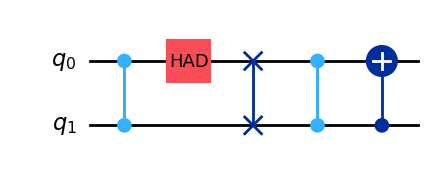

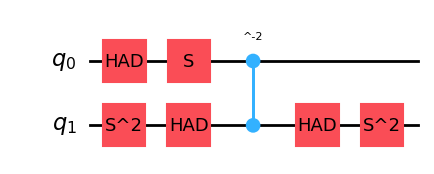

In [ ]:


lhs = dizx.Circuit(qudit_amount=2, dim=3)
lhs += CZ(0,1)
lhs += HAD(0)
lhs += SWAP(0,1)
lhs += CZ(0,1)
lhs += CX(1,0)
rhs = dizx.Circuit(qudit_amount=2, dim=3)
rhs += S(1)**2 + HAD(0)
rhs += S(0) + HAD(1)
rhs += CZ(0,1,2)**2
rhs += HAD(1) + S(1)**2

display(lhs.draw())
display(rhs.draw())

## Print each single-qupit box relation to two qasm files

In [41]:
name_of_file = 'BR1-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR1_lhs:
    fBR1_lhs.write(BR1lhs.to_qasm())
name_of_file = 'BR1-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR1_rhs:
    fBR1_rhs.write(BR1rhs.to_qasm())

name_of_file = 'BR2-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR2_lhs:
    fBR2_lhs.write(BR2lhs.to_qasm())
name_of_file = 'BR2-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR2_rhs:
    fBR2_rhs.write(BR2rhs.to_qasm())

name_of_file = 'BR3-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR3_lhs:
    fBR3_lhs.write(BR3lhs.to_qasm())
name_of_file = 'BR3-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR3_rhs:
    fBR3_rhs.write(BR3rhs.to_qasm())

name_of_file = 'BR4-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR4_lhs:
    fBR4_lhs.write(BR4lhs.to_qasm())
name_of_file = 'BR4-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR4_rhs:
    fBR4_rhs.write(BR4rhs.to_qasm())

name_of_file = 'BR5-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR5_lhs:
    fBR5_lhs.write(BR5lhs.to_qasm())
name_of_file = 'BR5-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR5_rhs:
    fBR5_rhs.write(BR5rhs.to_qasm())

name_of_file = 'BR6-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR6_lhs:
    fBR6_lhs.write(BR6lhs.to_qasm())
name_of_file = 'BR6-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR6_rhs:
    fBR6_rhs.write(BR6rhs.to_qasm())

In [48]:
# print("BR1-LHS:")
# display(BR1lhs.draw())
# print("BR1-RHS:")
# display(BR1rhs.draw())

# print("BR2-LHS:")
# display(BR2lhs.draw())
# print("BR2-RHS:")
# display(BR2rhs.draw())

# print("BR3-LHS:")
# display(BR3lhs.draw())
# print("BR3-RHS:")
# display(BR3rhs.draw())

# print("BR4-LHS:")
# display(BR4lhs.draw())
# print("BR4-RHS:")
# display(BR4rhs.draw())

# print("BR5-LHS:")
# display(BR5lhs.draw())
# print("BR5-RHS:")
# display(BR5rhs.draw())

# print("BR6-LHS:")
# display(BR6lhs.draw())
# print("BR6-RHS:")
# display(BR6rhs.draw())

In [ ]:
primes = [3, 5, 7, 11, 13, 19, 23]
for p in primes:
    if dizx.symplectic.compare_matrices2(BR1lhs.to_symplectic_matrix(), BR1rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 1 fails.")
    if dizx.symplectic.compare_matrices2(BR2lhs.to_symplectic_matrix(), BR2rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 2 fails.")
    if dizx.symplectic.compare_matrices2(BR3lhs.to_symplectic_matrix(), BR3rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 3 fails.")
    if dizx.symplectic.compare_matrices2(BR4lhs.to_symplectic_matrix(), BR4rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 4 fails.")
    if dizx.symplectic.compare_matrices2(BR5lhs.to_symplectic_matrix(), BR5rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 5 fails.")
    if dizx.symplectic.compare_matrices2(BR6lhs.to_symplectic_matrix(), BR6rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 6 fails.")

3
5
7
11
13
19
23
23


In [ ]:
import os



# --- 2. Loop through all relations ---
for name, lhs, rhs in zip(relation_names, lhs_list, rhs_list):

    # Compute symplectic matrices
    lhs_mat = lhs.to_symplectic_matrix()
    rhs_mat = rhs.to_symplectic_matrix()

    # Compare using your function
    ok = dizx.symplectic.compare_matrices2(lhs_mat, rhs_mat, modulus=p)

    if not ok:
        print(f"{name} fails.")

        # --- 3. Save LHS and RHS QASM files ---
        lhs_filename = os.path.join(save_to_path, f"{name}-lhs.qasm")
        rhs_filename = os.path.join(save_to_path, f"{name}-rhs.qasm")

        with open(lhs_filename, "w+") as f:
            f.write(lhs.to_qasm())

        with open(rhs_filename, "w+") as f:
            f.write(rhs.to_qasm())

        # Optional: stop after the first failure
        # break

    else:
        print(f"{name} OK.")

BR1 OK.
BR2 OK.
BR3 OK.
BR4 OK.
BR5 OK.
BR6 OK.


In [ ]:
from sympy import symbols
a = symbols("a")
ainv = symbols("ainv")
b = symbols("b")
binv = symbols("binv")
Aab = dizx.Circuit(qudit_amount=1, dim=p)
Aab += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b+1)) + H
A0b = dizx.Circuit(qudit_amount=1, dim=p)
A0b += H**-1 + S**binv + H**-1 + S**b + H
m = A0b.to_symplectic_matrix()
print(m)
print(dizx.symplectic.reduce_matrix(m,[(a,ainv),(b,binv)]))
BR1lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR1rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR1lhs += S + A0b
BR1rhs += A0b + (S**binv)**binv
mlhs = BR1lhs.to_symplectic_matrix()
print("S.A0b")
print(mlhs)
print(dizx.symplectic.reduce_matrix(mlhs,[(a,ainv),(b,binv)]))
BR1rhs += A0b + (S**binv)**binv
mrhs = BR1rhs.to_symplectic_matrix()
print("A0b.dir")
print(mrhs)
print(dizx.symplectic.reduce_matrix(mrhs,[(a,ainv),(b,binv)]))
# primes = [3, 5, 7, 11, 13, 19, 23]
# for p in primes:
#     BR1lhs = dizx.Circuit(qudit_amount=1, dim=p)
#     BR1rhs = dizx.Circuit(qudit_amount=1, dim=p)
#     BR1lhs += S + A0b
#     BR1rhs += A0b + (S**binv)**binv
#     print(dizx.symplectic.compare_matrices(BR1lhs.to_symplectic_matrix(), BR1rhs.to_symplectic_matrix(), modulus=p))

Matrix([[b, -b*binv + 1], [-1, binv]])
Matrix([[b, 0], [-1, binv]])
S.A0b
Matrix([[-b*(binv - 1) + 1, -b*binv + 1], [binv - 1, binv]])
Matrix([[b, 0], [binv - 1, binv]])
A0b.dir
Matrix([[b*binv**2 - b*(-b + binv*(b*binv**2 - 1)) - 1, -b*(b*binv + binv*(binv**2*(-b*binv + 1) + binv) - 1) + binv**2*(-b*binv + 1) + binv], [-b + binv**2*(b*binv**2 - b*(-b + binv*(b*binv**2 - 1)) - 1) + binv*(b*binv**2 - 1), b*binv + binv**2*(-b*(b*binv + binv*(binv**2*(-b*binv + 1) + binv) - 1) + binv**2*(-b*binv + 1) + binv) + binv*(binv**2*(-b*binv + 1) + binv) - 1]])
Matrix([[b**2, 0], [-b + binv**2 - binv + 1, binv**2]])


In [5]:
from sympy import symbols
a = symbols("a")
ainv = symbols("ainv")
b = symbols("b")
binv = symbols("binv")
Hadj = dizx.gates.HAD(0,adjoint=True)
H = dizx.gates.HAD(0)
S = dizx.gates.S(0)

lhs = dizx.Circuit(qudit_amount=1, dim=3)
lhs += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b+1)) + H

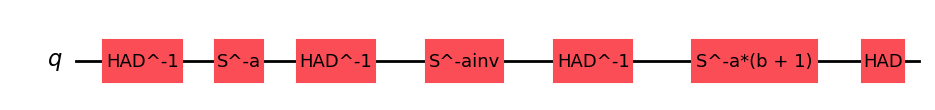

In [6]:
lhs.draw()

Matrix([[1, 0], [a, 1]])


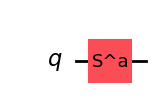

In [12]:
# C1
lhs = dizx.Circuit(qudit_amount=1, dim=5)
# S1 = S(1, 2, a)
# lhs += S1
# S0 = S(0,1)
lhs += S ** a
print(lhs.to_symplectic_matrix())
display(lhs.draw())

In [3]:
c = dizx.Circuit(qudit_amount=2,dim=3)
c.add_gates("H H S",0)
# c.add_gate("CZ",0,1)
# c.add_gates("S S H",1)
# c.add_gates("H S", 0)

In [4]:
print(c)

Circuit[3](2 qudits, 0 dits, [HAD(0), HAD(0), S(0)] gates)


In [12]:
# Experimenting with sympy's finite fields over polynomials
# Attempt 1 using Polynomial rings

from sympy import symbols, groebner, Matrix
from sympy.polys.domains import GF, PolynomialRing
from sympy.polys.matrices import DomainMatrix

p = 7
F = GF(p)
beta = symbols("beta")
b = symbols("b")
a = symbols("a")
ainv = symbols("a^{-1}")

# Polynomial ring GF(p)[a]
R = PolynomialRing(F, [a,ainv,b])

# testing
# R = PolynomialRing(F, [a,ainv,b,beta])

Ra = R.convert(a)
Rainv = R.convert(ainv)
# Rbeta = R.convert(beta)
Rb = R.convert(b)

G = groebner([a*ainv - 1], a, ainv, modulus=p)

H = DomainMatrix([[R.convert(0), R.convert(-1)],
                  [R.convert(1), R.convert(0)]],
                 (2, 2), R)

Hinv = DomainMatrix([[R.convert(0), R.convert(1)],
                  [R.convert(-1), R.convert(0)]],
                 (2, 2), R)


def S_repetitions(rep):
    return DomainMatrix([[R.convert(1), R.convert(0)],
                  [rep, R.convert(1)]],
                 (2, 2), R)

# Sbeta = S_repetitions(Rbeta)
Sb = S_repetitions(Rb)
# Build a matrix with entries in GF(p)[a]
A = DomainMatrix([[R.convert(1), R.convert(0)],
                  [R.convert(b), R.convert(1)]],
                 (2, 2), R)

print("Matrix over GF(p)[a]:")
print(A.to_Matrix())

aval = F(3)  # element of GF(7)

# Substitute 'a=3' in each entry
# evaluated_entries = [[entry.evaluate(0,aval) for entry in row]
#                      for row in A.to_list()]

# # Build a new matrix over GF(p)
# A_eval = DomainMatrix(evaluated_entries, A.shape, F)

# print("Matrix evaluated at a=3 (in GF(7)):")
# print(A_eval.to_Matrix())

Matrix over GF(p)[a]:
Matrix([[1, 0], [b, 1]])


In [11]:
# Attempt 2 using groebner bases to automate the reductions of the variables and say a*ainv = 1.
G = groebner([a*ainv - 1], a, ainv, b, modulus=p)
expr = a**2*ainv + 3
G.reduce(expr)

H = Matrix([[0,-1],[1,0]])
Hinv = Matrix([[0,1],[-1,0]])
H2 = Matrix([[-1,0],[0,-1]])


def Sr(rep):
    return Matrix([[1,0],[rep,1]])

M = H*Sr(-a*(b+1))*Hinv*Sr(-ainv)*Hinv*Sr(-a)*Hinv

def reduce_matrix(M):
    evaluated_entries = []
    for i in range(M.rows):
        row = M.row(i)
        newrow = []
        for entry in row:
            entry = G.reduce(entry)[1]
            newrow.append(entry)
        evaluated_entries.append(newrow)
    return Matrix(evaluated_entries)

reduce_matrix(M)

Matrix([
[   b, -a],
[ainv,  0]])

# The Qupit Equality Checking

In [13]:
from sympy import Matrix, symbols, expand
from sympy.polys import groebner

# symbols and field
a, ainv, b = symbols('a ainv b')
# p = 101  # your modulus

# ideal: a*ainv = 1 over GF(p)
G = groebner([a*ainv - 1], a, ainv, b, order='lex', modulus=p)

def nf(expr):
    # reduced (normal-form) representative modulo <a*ainv-1> over GF(p)
    return G.reduce(expand(expr))[1]

def normalize_matrix(M):
    # apply reduction entrywise
    return M.applyfunc(nf)

def matrices_equal(A, B):
    # equal iff their difference reduces to 0
    R = normalize_matrix(A - B)
    return R == Matrix.zeros(*A.shape)

# example usage:
# M = ... (your matrix)
# N = ... (another matrix built the same way)
# are_equal = matrices_equal(M, N)
# print(are_equal)


# The Qutrit Equality Checking

In [14]:
def equalUpToScalar(U, V, tol=1e-10):
    """
    Check if two unitary matrices U and V are equal up to (-w)^t, 
    where w is the third root of unity and t is in Z6.

    Parameters:
    U : np.ndarray
        The first symplectic matrix
    V : np.ndarray
        The second symplectic matrix
    tol : float
        The numerical tolerance for equality checks (default: 1e-10).

    Returns:
    bool : True if U and V are equal up to a scalar, False otherwise.
    """
    # Compute the third root of unity w
    # w = np.exp(2j * np.pi / 3)

    # Define the all-zero matrix based on the dimension and data type of the input matrix
    # zero_matrix = np.zeros_like(U)
    zero_matrix = Matrix([[0,0],[0,0]])
    
    # When V = U
    if np.allclose(V - U, zero_matrix, rtol=0, atol=tol):
        print("Exactly equal")
        return True
    else:
        print("Not equal")
        return False
    

In [8]:
from sympy import Matrix

M = Matrix([[1,0],[a,1]])
M.inv()

Matrix([
[ 1, 0],
[-a, 1]])

# Confirm the Single-Qupit Symplectic Completeness

In [15]:
# Test 1
H2 = H * H
print(H2)

H3 = H * H * H
print(H3)

H4 = H * H * H * H
print(H4)

DomainMatrix([[6 mod 7, 0 mod 7], [0 mod 7, 6 mod 7]], (2, 2), GF(7)[a,a^{-1},b])
DomainMatrix([[0 mod 7, 1 mod 7], [6 mod 7, 0 mod 7]], (2, 2), GF(7)[a,a^{-1},b])
DomainMatrix([[1 mod 7, 0 mod 7], [0 mod 7, 1 mod 7]], (2, 2), GF(7)[a,a^{-1},b])


In [16]:
# Test 2
S = Sr(1)
print("S: ", S)

S2 = Sr(2)
reduce_S2 = reduce_matrix(S2)
print("S2: ", reduce_S2)

S3 = Sr(3)
reduce_S3 = reduce_matrix(S3)
print("S3: ", reduce_S3)

S4 = Sr(4)
reduce_S4 = reduce_matrix(S4)
print("S4: ", reduce_S4)

S5 = Sr(5)
reduce_S5 = reduce_matrix(S5)
print("S5: ", reduce_S5)

S6 = Sr(6)
reduce_S6 = reduce_matrix(S6)
print("S6: ", reduce_S6)

Sp = Sr(p)
reduce_Sp = reduce_matrix(Sp)
print("Sp: ", reduce_Sp)

Sp1 = Sr(p+1)
reduce_Sp1 = reduce_matrix(Sp1)
print("Sp+1: ", reduce_Sp1)

print(p)

S:  Matrix([[1, 0], [1, 1]])
S2:  Matrix([[1, 0], [2, 1]])
S3:  Matrix([[1, 0], [3, 1]])
S4:  Matrix([[1, 0], [-3, 1]])
S5:  Matrix([[1, 0], [-2, 1]])
S6:  Matrix([[1, 0], [-1, 1]])
Sp:  Matrix([[1, 0], [0, 1]])
Sp+1:  Matrix([[1, 0], [1, 1]])
7


In [17]:
# Test 3: Figure 1, single qupit
LHS = H * S * H * S * H * S
RHS = Matrix([[1,0],[0,1]])
print(LHS)
print(RHS)
print(matrices_equal(LHS, RHS))


LHS = H2 * S
RHS = S * H2
print(LHS)
print(RHS)
print(matrices_equal(LHS, RHS))

TypeError: cannot unpack non-iterable int object

In [13]:
# Test 4
input = Matrix([[a],[0]])
print(H * input)

input = Matrix([[0],[a]])
print(H * input)

input = Matrix([[0],[-a]])
print(H * input)

Matrix([[0], [a]])
Matrix([[-a], [0]])
Matrix([[a], [0]])


In [14]:
# Test 5
input = Matrix([[a],[0]])
print(S * input)

input = Matrix([[0],[a]])
print(S * input)

input = Matrix([[a],[-a]])
print(S * input)

Matrix([[a], [a]])
Matrix([[0], [a]])
Matrix([[a], [0]])


In [15]:
# Test 6
Sa = Sr(a)

input = Matrix([[1],[0]])
print(Sa * input)

input = Matrix([[0],[1]])
print(Sa * input)

input = Matrix([[1],[-a]])
print(Sa * input)

Matrix([[1], [a]])
Matrix([[0], [1]])
Matrix([[1], [0]])


In [16]:
# Test 7
Sb = Sr(b)

input = Matrix([[a],[0]])
print(Sb * input)

input = Matrix([[0],[a]])
print(Sb * input)

input = Matrix([[a],[-a * b]])
print(Sb * input)

Matrix([[a], [a*b]])
Matrix([[0], [a]])
Matrix([[a], [0]])


# Test multi-qudit gates

In [ ]:
# SWAP
SWAPmat
SWAP(0,2,4)

Matrix([
[0, 0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 0, 0, 1, 0, 0],
[0, 0, 1, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0],
[1, 0, 0, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 1, 0],
[0, 0, 0, 0, 0, 0, 0, 1]])

In [ ]:
# Hadamard
# H0 = H(0, 2, reps=1)
# print(H0)
H(1, 3, reps=1)
# H(1, 3, reps=2)
# H(1, 3, reps=3)
# H(1, 3, reps=5)
# H1 = H(1, 2, reps=1)

Matrix([
[1, 0, 0,  0, 0, 0],
[0, 1, 0,  0, 0, 0],
[0, 0, 0, -1, 0, 0],
[0, 0, 1,  0, 0, 0],
[0, 0, 0,  0, 1, 0],
[0, 0, 0,  0, 0, 1]])

Matrix([[1, 0], [a, 1]])


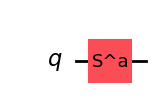

In [62]:
# def S(target, num_qudits, reps=1):
#     mat = Smat(reps)
#     return embed_block(mat, num_qudits, [target])
lhs = dizx.Circuit(qudit_amount=1, dim=5)
# S1 = S(1, 2, a)
# lhs += S1
S0 = S(0)
lhs += S0 ** a
print(lhs.to_symplectic_matrix())
display(lhs.draw())

In [19]:
H0 = H(0, 2, reps=1)
H1 = H(1, 2, reps=1)
S1 = S(0, 2, reps=2)
# C14l = CZ * H0 * CZ * H0 * CZ * S1
# C14r = H0 * CZ * H0
print(H0 == H1)

False


In [65]:
from dizx.circuit.gates import CZ, CX, HAD, S#, Z, X

lhs = dizx.Circuit(qudit_amount=2, dim=5)
lhs += CZ(0,1)
lhs += HAD(0)**2 + HAD(1)
lhs += CZ(0,1)
lhs += CX(1,0)
rhs = dizx.Circuit(qudit_amount=2, dim=5)
rhs += HAD(1)
rhs += CZ(0,1) + CX(1,0)
rhs += S(1)**2 + HAD(1)**2 + S(1)**2
rhs += CX(0,1)**2
rhs += S(1)**2 #+ Z(1)

In [66]:
dizx.symplectic.compare_matrices(lhs.to_symplectic_matrix(), rhs.to_symplectic_matrix(), modulus=3)

True

LHS of BR1


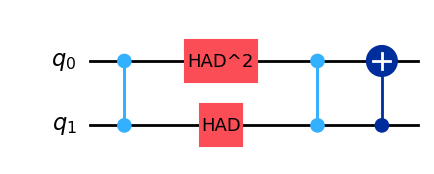

LHS of BR1


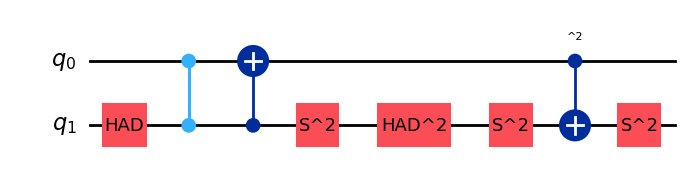

In [67]:
print("LHS of BR1")
display(lhs.draw())
print("LHS of BR1")
display(rhs.draw())

In [ ]:
r1-lhs = CZ * H0 * CZ * H0 * CZ * S1r(2)

primes = [3, 5, 7, 11, 13, 19, 23]
for p in primes:
    r1-lhs 

In [20]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import dizx
from dizx import Edge
from dizx import clifford_simplifier as simp
Phase = dizx.CliffordPhase
d = 3
Z = dizx.VertexType.Z
X = dizx.VertexType.X

In [19]:
from sympy import symbols
a = symbols("a")
ainv = symbols("ainv")
b = symbols("b")
binv = symbols("binv")
Hadj = dizx.gates.HAD(0,adjoint=True)
H = dizx.gates.HAD(0)
S = dizx.gates.S(0)

lhs = dizx.Circuit(qudit_amount=1, dim=3)
lhs += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b+1)) + H

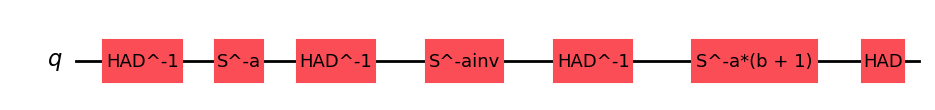

In [20]:
lhs.draw()